In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,Normalizer,MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree 

In [ ]:
# x=np.array([1,2,3,4,5])
# y=np.array([2,4,5,4,5])
# # print(x,y)

In [28]:
mean_x=np.mean(x)
mean_y=np.mean(y)

print(f"menas of x is :{mean_x}")
print(f"menas of y is :{mean_y}")

menas of x is :34890.0775
menas of y is :0.3575


In [27]:
num=np.sum((x-mean_x)*(y-mean_y))
num
deno=np.sum((x-mean_x)**2)
deno

10.0

In [29]:
slope=num/deno
print(slope)

0.6


In [31]:
intercept=mean_y-slope*mean_x
intercept

2.2

In [33]:
manual_pread=slope*x+intercept
manual_pread

array([2.8, 3.4, 4. , 4.6, 5.2])

In [50]:
9x_reshaped=x.reshape(-1,1)
x_reshaped

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [34]:
model=LinearRegression()

In [51]:
x_reshaped.shape

(5, 1)

In [54]:
y=y.reshape(1,-1)
y
# y.shape

array([[2, 4, 5, 4, 5]])

In [12]:
x=np.array([[1],[2],[3],[4],[5]])
y=np.array([0,0,0,1,1])

In [13]:
model=LogisticRegression()
model.fit(x,y)

LogisticRegression()

In [34]:
 x_test=np.linspace(0,6,10).reshape(-1,1) # it create line interval bw line to gether data 
prob=model.predict_proba(x_test)
 # print(prob)


In [32]:
y_pred=model.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [35]:
import matplotlib.pyplot as plt

In [ ]:
plt.scatter(x,y,color="red")
plt.scatter(x_test,y,color="red")
plt.scatter(x_test,prob[:0],cpolr

In [5]:
df=pd.read_csv("social.csv")
x=df.iloc[:,2:4]
y=df.iloc[:,4] # using 1:3 as indicies will give an array of dim (10,1)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [31]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [32]:
x_sca=StandardScaler()
x_train=x_sca.fit_transform(x_train)
x_test=x_sca.transform(x_test)

In [60]:
clf= DecisionTreeClassifier(criterion="entropy",random_state=0)  # we can use ginni index inplace of entropy as well so it will work on that bases
clf.fit(x_train,y_train)


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [34]:
y_pread=clf.predict(x_test)
y_pread

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1], dtype=int64)

In [35]:
acc=accuracy_score(y_test,y_pread)
acc

0.91

In [48]:
clf_report=classification_report(y_test,y_pread)
print(clf_report)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        68
           1       0.83      0.91      0.87        32

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



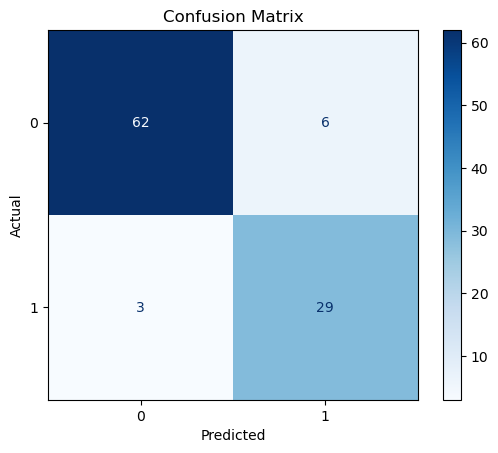

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pread)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

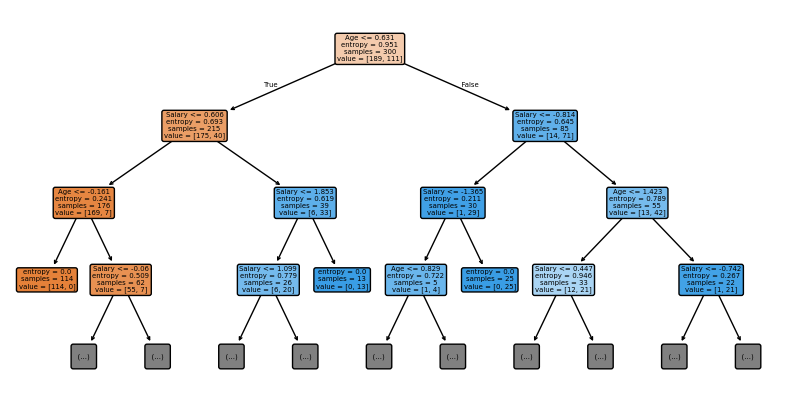

In [59]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,5))
plot_tree(clf,
         max_depth=3,
         feature_names=("Age","Salary"),
        filled=True,rounded=True,fontsize=5)

plt.show()

In [79]:
from sklearn.datasets import load_iris
iris=load_iris()
x,y=iris.data,iris.target

In [80]:
model= DecisionTreeClassifier(criterion="entropy",random_state=0)  # we can use ginni index inplace of entropy as well so it will work on that bases
model.fit(x,y)

DecisionTreeClassifier(criterion='entropy', random_state=0)

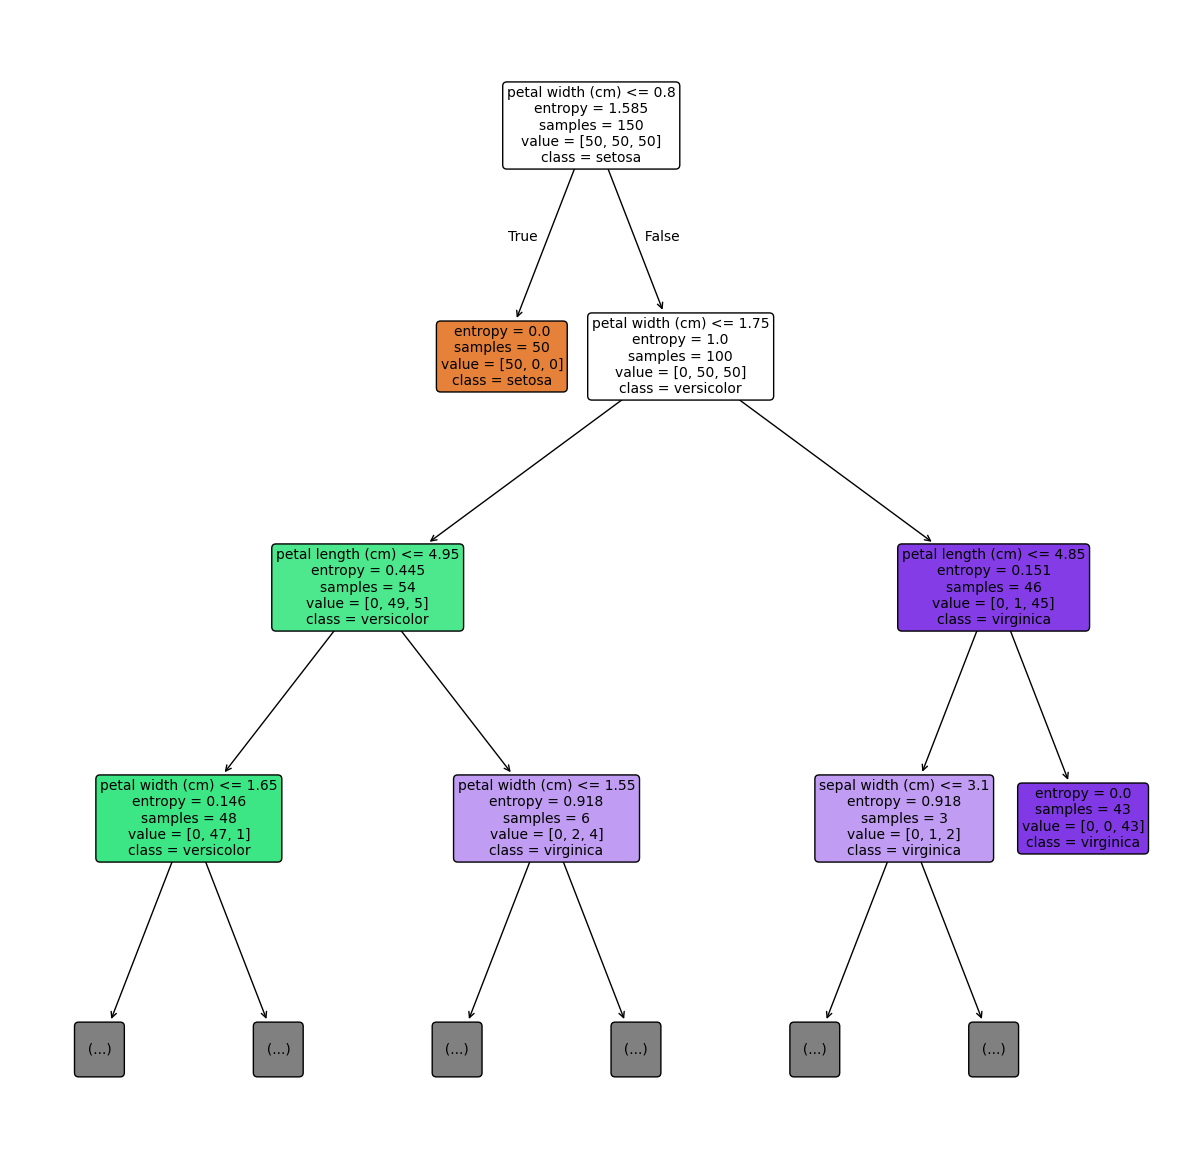

In [83]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,15))
plot_tree(model,
         max_depth=3,
         feature_names=iris.feature_names,
          class_names=iris.target_names,
        filled=True,rounded=True,fontsize=10)

plt.show()